In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid
from scipy.integrate import solve_ivp


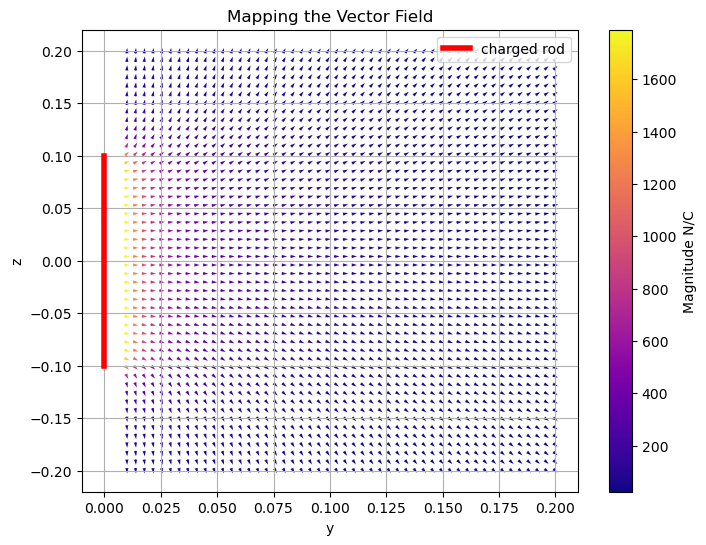

In [11]:
#Task 1: Mapping the Vector Field (Ey, Ez)
k_coulomb = 8.99e9  # N m^2 / C^2

def calculate_electric_field(y_obs, z_obs, L=0.2, lam=1e-9): #Lam= Linear charge distribution
    n_segments = 50
    z_points = np.linspace(-L/2, L/2, n_segments)
    dz = z_points[1] - z_points[0]
    r_dist = np.sqrt(y_obs**2 + (z_obs - z_points)**2)
    ey = k_coulomb * lam * np.sum(y_obs / r_dist**3) * dz
    ez = k_coulomb * lam * np.sum((z_obs - z_points) / r_dist**3) * dz
    return ey, ez    
   
y_range = np.linspace(0.01, 0.2, 50)  # Perpendicular distance from the rod
z_range = np.linspace(-0.2, 0.2, 50)  # Position along/parallel to the rod
Y, Z = np.meshgrid(y_range, z_range)

# 2. CALCULATE POTENTIAL AT EVERY GRID POINT
Ey_map = np.zeros(Y.shape)   #shape of Y
Ez_map = np.zeros(Y.shape)
for i in range(Z.shape[0]):
    for j in range(Y.shape[1]):
        Ey_map[i, j], Ez_map[i, j] = calculate_electric_field(Y[i,j], Z[i,j])
e_mag = np.sqrt(Ey_map**2 + Ez_map**2)

eps= 1e-20
Ey_norm = Ey_map/(e_mag + eps)
Ez_norm = Ez_map/(e_mag + eps)

plt.figure(figsize=(8,6))
plt.quiver(Y, Z, Ey_norm, Ez_norm, e_mag, cmap='plasma', pivot='mid')
plt.colorbar(label='Magnitude N/C')
#plot the rod
plt.plot([0,0],[-0.1,0.1], linewidth=4,label='charged rod', color='red')
plt.title("Mapping the Vector Field")
plt.xlabel('y')
plt.ylabel('z')
plt.legend()
plt.grid()

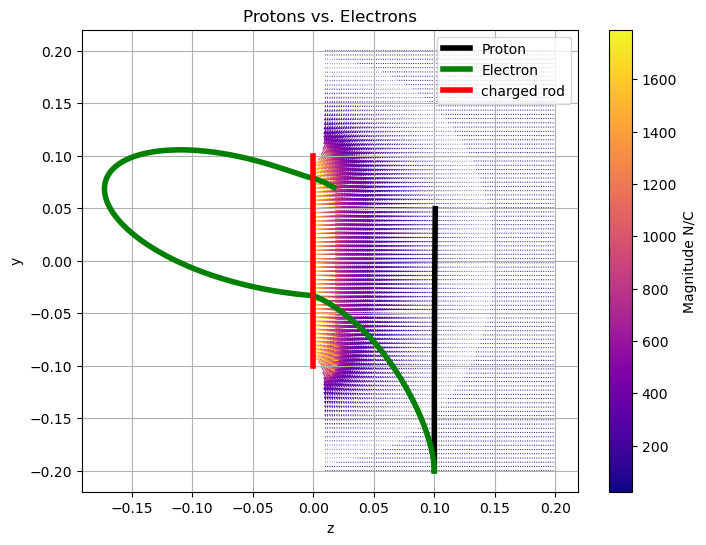

In [9]:
'''Task 2: Protons vs. Electrons (Dynamics)
Using scipy.integrate.solve_ivp, "fire" two different particles through your field starting at (y=0.1, z=-0.2) with velocity vz = 5 ×105 m/s.

The Comparison: Plot the proton (repelled) and the electron (attracted) on the same graph as your field map.
Analysis: Why does the electron path look so much more "curved" than the proton path, even though they experience the same magnitude of field?'''

y = 0.01
z = -0.2
vy0,vz0 = 0, 5e5
q_p = 1.602*(10**-19)
p_mass = 1.672*(10**-27)
q_e = -1.602*(10**-19)
e_mass = 9.109*(10**-31) 

def dynamics(t, u, q, m):
    y, z, vy, vz = u
    Ey, Ez = calculate_electric_field(y, z)
    ay = q * Ey / m
    az = q * Ez / m
    return [vy, vz, ay, az]



u0 = [0.1, -0.2, 0.0, 5e5]   # y0, z0, vy0, vz0
t_span = (0, 5e-7)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

sol_proton = solve_ivp(dynamics, t_span, u0, t_eval=t_eval,
                       args=(q_p, p_mass))

sol_electron = solve_ivp(dynamics, t_span, u0, t_eval=t_eval,
                         args=(q_e, e_mass))


'''def particle_path(t, state, q, m):
    
    dt = np.linspace(-1, 1, 50)
    ay = ((Ey*q)/m)*dt**2
    az = ((Ez*q)/m)*dt**2
    
    y = 1/2*
    z = vz*dt + z'''

plt.figure(figsize=(8,6))
plt.quiver(Y, Z, Ey_map, Ez_map, e_mag, cmap='plasma', pivot='mid')
plt.colorbar(label='Magnitude N/C')
plt.plot(sol_proton.y[0], sol_proton.y[1], label= 'Proton', linewidth=4, color= 'black')
plt.plot(sol_electron.y[0], sol_electron.y[1], label= 'Electron', linewidth=4, color= 'green')
#plot the rod
plt.plot([0,0],[-0.1,0.1], linewidth=4,label='charged rod', color='red')
plt.title("Protons vs. Electrons")
plt.xlabel('z')
plt.ylabel('y')
plt.legend()
plt.grid()

In [4]:
#Task 3: Verification (The Two Limits)
def calculate_electric_field(y_obs, z_obs, L=0.2, lam=1e-9, n_segments=1000):
    z_points = np.linspace(-L/2, L/2, n_segments)
    dz = z_points[1] - z_points[0]
    r_dist = np.sqrt(y_obs**2 + (z_obs - z_points)**2)

    ey = k_coulomb * lam * np.sum(y_obs / r_dist**3) * dz
    ez = k_coulomb * lam * np.sum((z_obs - z_points) / r_dist**3) * dz

    return ey, ez


L = 0.2
lam = 1e-9

y_far = 5.0
z_far = 0.0

Ey_num, _ = calculate_electric_field(y_far, z_far, L=L, lam=lam, n_segments=1000)

Q = lam * L
Ey_point = k_coulomb * Q / y_far**2

rel_error_point = (Ey_num - Ey_point) / Ey_point
print("Ey_num (far)   =", Ey_num)
print("Ey_point (far) =", Ey_point)
print("Relative error (point limit) =", rel_error_point)

y_near = 1e-3
z_near = 0.0

Ey_num_near, Ez_num_near = calculate_electric_field(y_near, z_near, L=L, lam=lam, n_segments=1000)

Ey_inf = 2 * k_coulomb * lam / y_near

rel_error_inf = (Ey_num_near - Ey_inf) / Ey_inf
print("Ey_num (near)   =", Ey_num_near)
print("Ey_inf (near)   =", Ey_inf)
print("Relative error (infinite-line limit) =", rel_error_inf)


Ey_num (far)   = 0.07197756910334999
Ey_point (far) = 0.07192000000000001
Relative error (point limit) = 0.000800460280172063
Ey_num (near)   = 17979.10286514217
Ey_inf (near)   = 17980.0
Relative error (infinite-line limit) = -4.9896265730293595e-05


In [5]:
#Task 4: Physical Discussion
'''
Symmetry: Why is a 2D slice (Y, Z) sufficient to understand the field of a 3D cylindrical rod?
- The field of a charged rod does not change in the z direction, only in the y direction. It depends on the distance(radius) from the rod of the observer or point charge.
2.) Convergence: How many segments did you need in your trapezoid call before the "Infinite Line Limit" error dropped below 1%?
- The Infinite Line Limit error drops and stays below 1% when the segments are more than 1000. '''


'\nSymmetry: Why is a 2D slice (Y, Z) sufficient to understand the field of a 3D cylindrical rod?\n- The field of a charged rod does not change in the z direction, only in the y direction. It depends on the distance(radius) from the rod of the observer or point charge.\n2.) Convergence: How many segments did you need in your trapezoid call before the "Infinite Line Limit" error dropped below 1%?\n- The Infinite Line Limit error drops and stays below 1% when the segments are more than 1000. '

In [6]:
#Task 5: The Safety Zone (Parameter Search)
'''Find the Minimum Initial Velocity (v0) a proton needs so that it doesn't get pushed further than 15cm away from the rod (y < 0.15) as it passes by.'''


q_p = 1.602*10**-19
p_mass = 1.672*(10**-27)
y_max = 0.15
y0 = 0.01
z0 = -0.2

def dynamics(t, u):
    y, z, vy, vz = u
    Ey, Ez = calculate_electric_field(y, z)
    ay = q * Ey / p_mass
    az = q * Ez / p_mass
    return [vy, vz, ay, az]

def initial_velocity(v0):
    u0 = [0.1, -0.2, 0.0, v0]   # y0, z0, vy0, vz0
    t_span = (0, 5e-7)
    t_eval = np.linspace(t_span[0], t_span[1], 2000)

    sol_proton = solve_ivp(dynamics, t_span, u0, t_eval=t_eval,
                       args=(q_p, p_mass))
    y_traj = sol.y[0]
    return np.max(y_traj)

v_min= 1e3
v_max= 136
while v_max - v_min > 1e2:
    v_mid= 0.5* (v_max + v_min)
    if initial_velocity(v_mid) < y_max:
        v_max = v_mid
    else:
        v_min = v_mid

print(f"Minimum initial velocity: {v_max:.2f} m/s")

    #v = (1/2)* (Ey*q_p) / p_mass* dt + v0*dt

Minimum initial velocity: 136.00 m/s


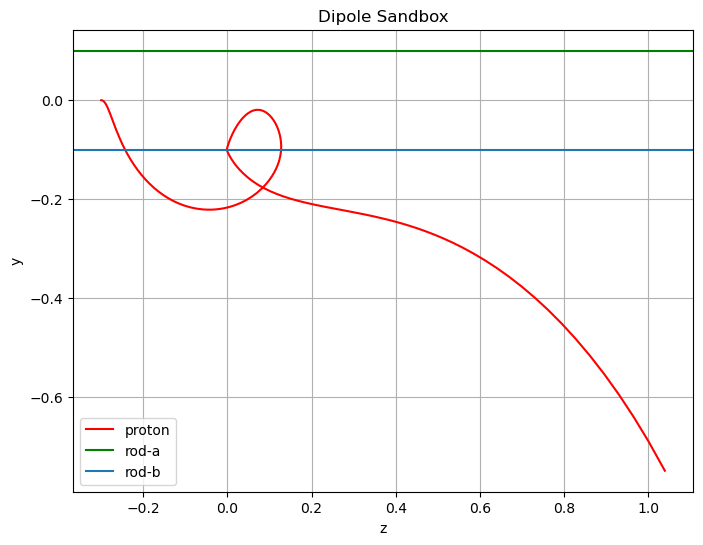

In [12]:
#Task 6: The Dipole Sandbox (Complex Space)
q_p = 1.602e-19    # C
p_mass = 1.673e-27 #kg
lam_a = 1e-8
lam_b = -1e-8
k = 899e9
rod_lam = 1e-9

y_a = +0.1
y_b = -0.1
rod_len = 0.2 #m

y0 = 0.0
z0 = -0.3
vy0= 1e3
vz0= 1e5
t_span= [0, 5e-6]

def rod_field(y, z, rod_lam, y_rod, num_segments=100):
    dz = np.linspace(-rod_len/2, rod_len/2, num_segments)
    dy = y - y_rod
    r = np.sqrt(dy**2 + (z-dz)**2)
    Ey = np.sum(k*rod_lam*dy/r**3 * (rod_len/num_segments))
    Ez = np.sum(k*rod_lam * (z-dz)/r**3 * (rod_len/num_segments))
    return Ey, Ez
def dipole_field(y,z,num_segments=200):
    Ey_a, Ez_a = rod_field(y,z,lam_a,y_a,num_segments)
    Ey_b, Ez_b = rod_field(y,z,lam_b,y_b,num_segments)
    return Ey_a + Ey_b, Ez_a + Ez_b
def dynamics(t, u):
    y, z, vy, vz = u
    Ey, Ez = dipole_field(y, z)
    ay = q_p * Ey / p_mass
    az = q_p * Ez / p_mass
    return [vy, vz, ay, az]

t_eval = np.linspace(t_span[0], t_span[1], 200)

sol = solve_ivp(dynamics, t_span, [y0, z0, vy0, vz0], method= 'RK45', rtol= 1e-8)
plt.figure(figsize=(8,6))
plt.plot(sol.y[1], sol.y[0], label= 'proton', color='red')
plt.axhline(y_a, label='rod-a', color='green')
plt.axhline(y_b, label='rod-b')
plt.title('Dipole Sandbox')
plt.xlabel('z')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()